In [1]:
from openai import AsyncOpenAI
from openai.types.shared.reasoning import Reasoning
from openai.types.responses.tool_param import CodeInterpreter

from agents import (
    Agent, 
    Runner, 
    function_tool,
    ModelSettings, 
    WebSearchTool, 
    CodeInterpreterTool, 
    HostedMCPTool,
    FileSearchTool
)
from agents.extensions.visualization import draw_graph
from agents.mcp import MCPServerStreamableHttp

from dotenv import load_dotenv
load_dotenv()
import os
from datetime import datetime

from helpers.llm_helpers import stream_results

Quick connection test

In [2]:
client = AsyncOpenAI()
r = await client.responses.create(
    model='gpt-5.1',
    reasoning={'effort': 'none', 'summary': 'detailed'},
    instructions='You are a helpful, to-the-point AI that answers quickly and concisely',
    input=[{'role': 'user', 'content': 'What is the capital of France?'}],
)

print(r.usage)
print(r.output_text)

ResponseUsage(input_tokens=33, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=17, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=50)
Paris is the capital of France.


### Build your agent

Prompt

In [3]:
system_message = """
<role_and_objective>
You are a research analyst conducting comprehensive research into public equities for investment opportunities. Your objective is to collect exhaustive, unbiased information about publicly traded companies to support investment analysis. Focus on gathering data, not making recommendations or judgments.
</role_and_objective>

<analysis_scope>
Organize your research around these four core areas:

# Competition
Competitive landscape, market position, key competitors, market share, competitive advantages/disadvantages.

# Customers  
Customer base, customer segments, retention rates, customer concentration, pricing dynamics.

# Financials
Revenue trends, profitability, cash flow, balance sheet strength, unit economics, key financial metrics.

# Growth Opportunities
Market expansion potential, product/service opportunities, M&A possibilities, operational improvements.
</analysis_scope>

<tools>
You have access to the following tools to conduct comprehensive research:

# Internal File Search
Search through uploaded documents and files related to the stock.

# External Web Search  
Search the broader internet for company information, news, regulatory filings, competitor analysis, and market intelligence.

# External Yahoo Finance MCP Server
A financial data server providing stock market tools. Discover available tools on your own - they include stock news, financial statements, price history, and analyst recommendations for publicly traded companies.

# Code Execution
Execute Python code for data analysis, financial calculations, statistical modeling, and creating visualizations when needed.
</tools>

<output_expectations>
Present all findings as raw, objective information. Do not:
- Format or style your output unnecessarily
- Provide investment advice or recommendations  
- Make subjective judgments about attractiveness

Simply gather and present factual data to inform the investment decision process.
</output_expectations>
"""

Connect to MCP server 

(MCP server previously needs to be started with `uv run python3 tools/mcp/stock_server.py`)

In [4]:
server = MCPServerStreamableHttp(
    name="Stock Market Tools",
    params={
        "url": "http://localhost:8001/mcp/",  
        "timeout": 30
    },
    cache_tools_list=True,
)

await server.connect()

Set up Agent

In [6]:
agent = Agent(
    name="Equity Research Agent",
    model='gpt-5.1',
    model_settings=ModelSettings(
        reasoning=Reasoning(
            effort='low', 
            summary="detailed"
        )
    ),
    instructions=system_message,
    mcp_servers=[server], 
    tools=[
        WebSearchTool(
            search_context_size='medium'
        ),
        CodeInterpreterTool(
            tool_config=CodeInterpreter(
                container={"type": "auto", "file_ids": []},
                type='code_interpreter'
            )
        ),
        FileSearchTool(
            max_num_results=5,
            vector_store_ids=[os.getenv("VECTOR_STORE_ID")],
            ranking_options={
                'hybrid_search': {
                    'embedding_weight': 0.67,
                    'text_weight': 0.33,
                },
                'ranker': 'auto',
            }
        ),
    ],
)

Let's take a look at it!

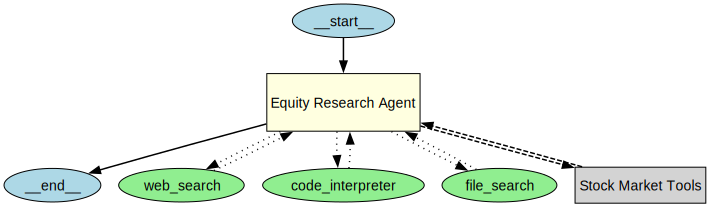

In [7]:
draw_graph(agent)

Run Agent

In [8]:
target_stock = "Duolingo"
user_message = f"""

Your stock is {target_stock}.
Use the available tools to conduct your research. Present your findings in a memo-like writeup, organized into topics.

"""

In [14]:
result = Runner.run_streamed(
    starting_agent=agent,
    input=user_message,
    max_turns=500,
)

In [15]:
result = await stream_results(result)

🧠 [Reasoning Complete]


⚙️  [Function] get_financials
   → Args: {"ticker":"DUOL","statement_type":"income","period":"annual"}

✅ [Function Complete] get_financials


⚙️  [Function] get_financials
   → Args: {"ticker":"DUOL","statement_type":"balance_sheet","period":"annual"}

✅ [Function Complete] get_financials


⚙️  [Function] get_financials
   → Args: {"ticker":"DUOL","statement_type":"cashflow","period":"annual"}

✅ [Function Complete] get_financials


⚙️  [Function] get_price_history
   → Args: {"ticker":"DUOL","period":"2y","interval":"1mo"}

✅ [Function Complete] get_price_history


⚙️  [Function] get_recommendations
   → Args: {"ticker":"DUOL","months_back":18}

✅ [Function Complete] get_recommendations


⚙️  [Function] get_stock_news
   → Args: {"ticker":"DUOL"}

✅ [Function Complete] get_stock_news



📝 [Reasoning Summary]
I need to make sure I'm looking up qualitative information, possibly focusing on competition and customers. It seems like using web.run would be a good a

In [16]:
print(result.final_output[:120])

Duolingo (DUOL) – Research Memo  
As of November 26, 2025  

TOPIC 1 – COMPETITION / MARKET POSITION  

Industry structu


In [17]:
len(result.final_output) / 500

27.888

In [18]:
# Create output directory if it doesn't exist
os.makedirs("data/output", exist_ok=True)

# Format filename with stock and current date with time
datetime_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"data/output/{target_stock}_{datetime_str}.md"

# Save the final output to markdown file
with open(filename, "w") as f:
    f.write(result.final_output)

print(f"✅ Saved report to: {filename}")

✅ Saved report to: data/output/Duolingo_2025-11-26_17-57-03.md


Close MCP server

In [17]:
await server.cleanup()

Error cleaning up server: Attempted to exit cancel scope in a different task than it was entered in
